<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Analysis" data-toc-modified-id="Analysis-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#B-cell-Receptor-analysis" data-toc-modified-id="B-cell-Receptor-analysis-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>B-cell Receptor analysis</a></span></li><li><span><a href="#ChipSeq" data-toc-modified-id="ChipSeq-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>ChipSeq</a></span><ul class="toc-item"><li><span><a href="#Chipseq-and-GWAS" data-toc-modified-id="Chipseq-and-GWAS-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Chipseq and GWAS</a></span></li><li><span><a href="#Fine-map-results-from-Mike-Cho" data-toc-modified-id="Fine-map-results-from-Mike-Cho-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Fine map results from Mike Cho</a></span></li><li><span><a href="#Partial-Correlation" data-toc-modified-id="Partial-Correlation-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Partial Correlation</a></span></li><li><span><a href="#ChipSeq---g1/g2-enrichment" data-toc-modified-id="ChipSeq---g1/g2-enrichment-1.2.4"><span class="toc-item-num">1.2.4&nbsp;&nbsp;</span>ChipSeq - g1/g2 enrichment</a></span></li></ul></li><li><span><a href="#PAX5-ADAM19" data-toc-modified-id="PAX5-ADAM19-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>PAX5-ADAM19</a></span><ul class="toc-item"><li><span><a href="#with-mirna-groups" data-toc-modified-id="with-mirna-groups-1.3.1"><span class="toc-item-num">1.3.1&nbsp;&nbsp;</span>with mirna groups</a></span></li></ul></li></ul></li></ul></div>

# Analysis

In [3]:
import pandas as pd
import os 
import seaborn as sns
from tqdm import tqdm
import sys,os
sys.path.append('/proj/regeps/regep00/studies/COPDGene/analyses/remge/PUMA_final/src/')
from utils_puma import *
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
from scipy.spatial.distance import cdist
from config import Config


#Expression Files
config = Config('bulk')
dict_input = get_processed_copdgene(config.path_dict_processed_input)
df_exp, df_pheno,df_mirna_pheno,df_corr,df_exp_mirna,list_case,list_control = dict_input['df_exp'], dict_input['df_pheno'], dict_input['df_pheno_mirna'],dict_input['df_corr'],dict_input['df_exp_mirna'],dict_input['list_case'],dict_input['list_control']
list_control_mirna,list_case_mirna = dict_input['list_control_mirna'],dict_input['list_case_mirna']
set_mirna,df_motif,dict_mirna_merging = dict_input['set_mirna'],dict_input['df_motif'],dict_input['dict_mirna_merging']

dict_ens_gene = get_dict_ens_gene()
dict_gene_ens = {y:x for x,y in dict_ens_gene.items()}

# Compare on the mirna groups obtained in the analysis
with open(config.path_nt_groups,'r') as f:
    dict_groups = json.load(f)
    
list_genes1_bulk = dict_groups['list_genes1']
list_genes2_bulk = dict_groups['list_genes2']
list_mirnas1_bulk = dict_groups['list_mirnas1']
list_mirnas2_bulk = dict_groups['list_mirnas2']


# Load Bcell
config_bcell = Config('bcell')
dict_input = get_processed_copdgene(config_bcell.path_dict_processed_input)
df_exp_bcell, df_pheno_bcell = dict_input['df_exp'], dict_input['df_pheno']


with open(config_bcell.path_nt_groups,'r') as f:
    dict_groups = json.load(f)
    
list_genes1_bcell = dict_groups['list_genes1']
list_genes2_bcell = dict_groups['list_genes2']
list_mirnas1_bcell = dict_groups['list_mirnas1']
list_mirnas2_bcell = dict_groups['list_mirnas2']


## B-cell Receptor analysis

In [10]:
def read_csv_bcr_lm(gene):
    df = pd.read_csv(config_bcell.get_lm_bcr_gene(gene))
    return df
dict_lm_stats_mrna = {gene:read_csv_bcr_lm(gene) for gene in tqdm(df_exp_bcell.index)}


100%|██████████| 2699/2699 [00:13<00:00, 198.10it/s]


In [11]:
def read_csv_bcr_lm(gene):
    print(config_bcell.get_lm_bcr_gene(gene))
    df = pd.read_csv(config_bcell.get_lm_bcr_gene(gene))
    return df


In [12]:
def get_stats_lm_from_dict(dict_lm_stats,list_1,list_2,list_other,name_lm,group_name='m'):
    def get_list_coef(list_mirna,group_name):
        list_coeff = []
        for mirna in list_mirna:
            tmp_df = dict_lm_stats[mirna].reset_index()
            try:
                tmp_df.Variable = tmp_df.Variable.str.replace(mirna,name_lm) 
            except:
                print('No lm for',mirna)
                continue
            tmp_df = tmp_df.set_index(['index',"Variable"])#[variable].rename(mirna)    
            tmp_df['reg'] = mirna
            list_coeff.append(tmp_df)
        
        df_coeff = pd.concat(list_coeff)#.T.reset_index()
        df_coeff['group'] = group_name
        
        return df_coeff

    df_coef_mirna1 = get_list_coef(list_1,group_name=group_name+'1')
    df_coef_mirna2 = get_list_coef(list_2,group_name=group_name+'2')
    df_coef_mirna_all = get_list_coef(list_other,group_name='other')
    df_coef_mirna = pd.concat([df_coef_mirna1,df_coef_mirna2,df_coef_mirna_all])
    return df_coef_mirna

In [13]:

print("Some LM didn't go through because gene expression had too low variance")
# Some LM didn't go through because gene expression had too low variance 
list_other_bcell = list(set(dict_lm_stats_mrna).difference(list_genes1_bcell+list_genes2_bcell))

df_coef_mrna = get_stats_lm_from_dict(dict_lm_stats_mrna,list_genes1_bcell,list_genes2_bcell,list_other_bcell,'gene',group_name='bG')
df_coef_mrna = df_coef_mrna.reset_index(level=1)
df_coef_mrna.Variable = df_coef_mrna.Variable.str.replace('standardize\(','').str.replace('\)','')
    


Some LM didn't go through because gene expression had too low variance
No lm for ENSG00000065320
No lm for ENSG00000221890
No lm for ENSG00000158955
No lm for ENSG00000174807
No lm for ENSG00000103034
No lm for ENSG00000137648
No lm for ENSG00000104848
No lm for ENSG00000076706
No lm for ENSG00000106633
No lm for ENSG00000171357
No lm for ENSG00000147799
No lm for ENSG00000160224
No lm for ENSG00000104368
No lm for ENSG00000117266
No lm for ENSG00000042781
No lm for ENSG00000147465
No lm for ENSG00000171759
No lm for ENSG00000112246
No lm for ENSG00000118004
No lm for ENSG00000184911
No lm for ENSG00000111664
No lm for ENSG00000266964
No lm for ENSG00000161594
No lm for ENSG00000179057
No lm for ENSG00000158816
No lm for ENSG00000140506
No lm for ENSG00000196557
No lm for ENSG00000188452
No lm for ENSG00000183615
No lm for ENSG00000177519


In [18]:
def rename_feat_bcr(x):
    if 'propCounts_' in x:
        x = x.replace('propCounts_','')
    if 'totMut_' in x:
        x = x.replace('totMut_','Mutations ')
    #x = x.replace('prop_mut_calassSwitch','Class switching')
    x = x.replace('prop_classSwitch','Class switching')
    
    return x

['bG1', 'bG2', 'PAX5', 'bG1', 'bG2', 'PAX5']


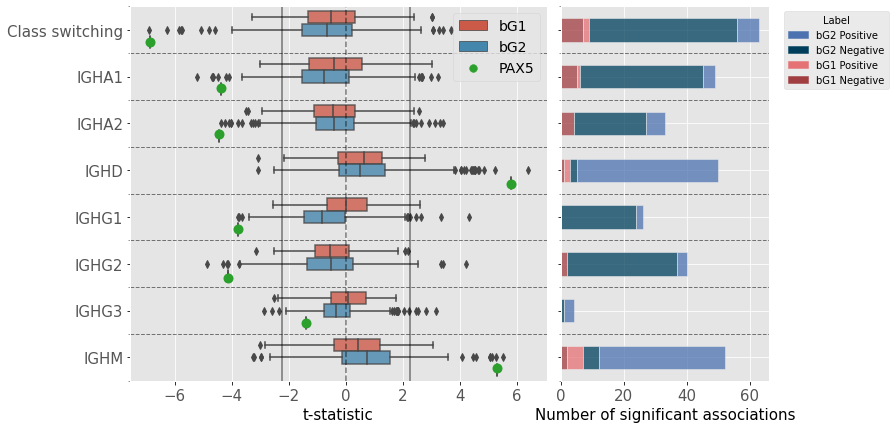

In [132]:
import matplotlib.patches as mpatches

from matplotlib.ticker import MultipleLocator
#sns.set_theme(font_scale=1.5)
import matplotlib.pyplot as plt
plt.style.use('ggplot')

tmp_copd = 'fev1fvc_thr'#'FEV1_FVC_utah' gold_ge2

# removed count_igsum, 'prop_unmut_classSwitch', 'prop_unmut_igMD', 'prop_mut_classSwitch','prop_mut_igMD'

list_bcr_sel = ['prop_classSwitch','propCounts_IGHA1','propCounts_IGHA2','propCounts_IGHD','propCounts_IGHG1','propCounts_IGHG2','propCounts_IGHG3','propCounts_IGHM']
               #'totMut_', 'totMut_IGHA1','totCount','totMut_IGHA2','totMut_IGHD','totMut_IGHG1','totMut_IGHG2','totMut_IGHG3','totMut_IGHM',]


df_filt = df_coef_mrna.query('index in @list_bcr_sel and reg in @df_exp_bcell.index  and group!="other"').reset_index().copy()
df_filt.loc[df_filt.reg==dict_gene_ens["PAX5"],'group'] = "PAX5"
df_filt['index'] = df_filt['index'].map(rename_feat_bcr)
df_sel = df_filt.query('Variable=="gene"')

x_order = {x:y for y,x in enumerate(sorted(set(df_sel['index']).union(df_sel['index'])))}
                            
df_sel = df_sel.append(pd.DataFrame({'index':list(set(x_order).difference(df_sel['index']))}))
df_sel = df_sel.sort_values('index')#, key = lambda x: x.replace(x_order))
                  
    


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [2, 1]})
ax1 = sns.boxplot(data = df_sel, hue = 'group', x='t',hue_order=['bG1','bG2','PAX5'],y = 'index',width=.8, boxprops=dict(alpha=.8),ax=ax1)    
sns.stripplot(data=df_sel.query('group=="PAX5"'), x="t", y="index",hue="group", hue_order=['bG1','bG2','PAX5'], size=10,palette=[sns.color_palette("tab10")[2]],dodge=True, ax=ax1)
#sns.scatterplot(data=df_sel.query('group==dict_gene_ens["PAX5"]'), x="t", y="index", size=8,  ax1=ax1)
handles, labels = ax1.get_legend_handles_labels()
print(labels)
ax1.legend(handles=handles[:2]+handles[-1:],
          labels=labels[:2]+labels[-1:],fontsize=14)
ax1.yaxis.set_minor_locator(MultipleLocator(.5))
ax1.yaxis.grid(True, which='minor', color='black', lw=1, alpha=.5,linestyle='--')

ax2.yaxis.set_minor_locator(MultipleLocator(.5))
ax2.yaxis.grid(True, which='minor', color='black', lw=1, alpha=.5,linestyle='--')

#ax1.set_ylim([df_sel1['index'].nunique()+1-.25,-.5])
ax1.set_ylabel('')
#ax1.set_title('Gene association', fontsize=15)
ax1.set_xlabel('t-statistic', fontsize=15, c='black')
ax2.set_xlabel('Number of significant associations', fontsize=15, c='black')
#plt.xticks(fontsize=20, c='black')
#plt.yticks(fontsize=20, c='black')
#ax1.tick_params(axis='x', colors='black')
ax1.axvline(0, c='black', alpha=.5,linestyle='--')

ax1.axvline(df_filt.query('adj_pval<0.05')['t'].abs().min(), c='black', alpha=.5,linestyle='-')
ax1.axvline(-df_filt.query('adj_pval<0.05')['t'].abs().min(), c='black', alpha=.5,linestyle='-',label='Significant Threshold')

df_sel['Sign'] = (df_sel['t']>0).astype(int).replace({0:'Negative',1:'Positive'})
df_sel['Label'] = df_sel['group'] + ' ' + df_sel['Sign']

#sns.histplot(data=df_sel.query('group!="PAX5" and adj_pval<0.05'), y="index", hue="group", multiple="stack", stat="count",ax=ax2,shrink=0.5, hue_order=['bG1','bG2'])
custom_palette = ["#4C72B0", "#003f5c","#E57376","#A13E41"] 



    
ax2 = sns.histplot(data=df_sel.query('group!="PAX5" and adj_pval<0.05'), y="index", hue="Label", 
             multiple="stack", stat="count",ax=ax2,shrink=0.5, hue_order = ['bG2 Positive','bG2 Negative','bG1 Positive','bG1 Negative'],
            palette= custom_palette)

# Manually create legend handles
handles = [
    mpatches.Patch(color=custom_palette[i], label=label)
    for i, label in enumerate(['bG2 Positive', 'bG2 Negative', 'bG1 Positive', 'bG1 Negative'])
]

# Add the custom legend outside the plot
ax2.legend(handles=handles, title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to avoid overlap
plt.tight_layout()
ax1.tick_params(axis='both', color='black',labelsize=15)
ax2.tick_params(axis='both', color='black',labelsize=15)


#plt.savefig(config_bcell.path_figures+'BCR_mRNA_groups_assiciation.png',dpi=500)


## ChipSeq

### Chipseq and GWAS

In [4]:
import pandas as pd
df_chipseq_pax5 = pd.read_csv(config.path_data+'Peaks_in_promoters_PAX5_GM12878_-250_+50.txt',header=None, sep='\t')
df_chipseq_pax5 = df_chipseq_pax5.drop_duplicates()
df_chipseq_pax5.columns = ['gene','Chr','init_region','end_region','cell_line']
df_chipseq_pax5.Chr = df_chipseq_pax5.Chr.str.replace('chr','')
df_chipseq_pax5 = df_chipseq_pax5[df_chipseq_pax5.Chr.str.isdigit()]#.drop('cell_line',axis=1)
df_chipseq_pax5.Chr = df_chipseq_pax5.Chr.astype(int)


In [5]:
df_gwas_hits = pd.read_csv(config.path_data+'copdLungFxCanonical - canonicalList_b37.annot.csv')
df_gwas_hits = df_gwas_hits.rename({'chr':'Chr'},axis=1)
df_gwas_hits = df_gwas_hits.dropna(subset=['Chr'])
df_gwas_hits = df_gwas_hits[df_gwas_hits.Chr.str.isdigit()]
df_gwas_hits.Chr = df_gwas_hits.Chr.astype(int)

print('Number of initial GWAS hits', df_gwas_hits.query('source_name in ["Shrine2022","Sakornsakolpat_2018"]').shape[0])

Number of initial GWAS hits 1166


In [6]:
df_gwas_hits.query('source_name in ["Shrine2022","Sakornsakolpat_2018"] and trait in ["FEV1/FVC", "modCOPD"] and p<0.0000001')

,source_name,source_PMID,ancestry,trait,Chr,pos_b37,pos_b38,marker_b37,rsid,replication,...,beta,se,p,N,conditionedOn,priorSnp,otherRiskAllele,notes,leadFunc,evidence
3,Shrine2022,NaN,mixed,FEV1/FVC,1,3431555.0,3514991.0,1:3431555:C:T,rs947350,NaN,...,0.0020,0.0002,1.490000e-20,575967.0,NaN,NaN,NaN,NaN,NaN,"MEGF6(WES,nearest), CEP104(rare_disease), FAM2..."
5,Shrine2022,NaN,mixed,FEV1/FVC,1,6678864.0,6618804.0,1:6678864:A:C,rs9661802,NaN,...,0.0014,0.0001,1.780000e-23,577206.0,NaN,NaN,NaN,NaN,NaN,"PHF13(WES,nearest), THAP3(eQTL,PoPs), RP11-58A..."
10,Shrine2022,NaN,mixed,FEV1/FVC,1,9494240.0,9434181.0,1:9494240:A:G,rs72864356,NaN,...,0.0016,0.0002,1.200000e-12,577219.0,NaN,NaN,NaN,NaN,NaN,"KIF1B(eQTL), LOC100506022(nearest), PGD(eQTL),..."
13,Sakornsakolpat_2018,30804561.0,Mixed,modCOPD,1,17306029.0,16979534.0,1:17306029:C:A,rs9435731,strict,...,0.0613,0.0099,6.550000e-10,NaN,NaN,NaN,NaN,NaN,intronic,NaN
14,Shrine2022,NaN,mixed,FEV1/FVC,1,17306029.0,16979534.0,1:17306029:A:C,rs9435731,NaN,...,-0.0023,0.0001,6.280000e-64,577203.0,NaN,NaN,NaN,NaN,NaN,"MFAP2(PoPs,nearest), MST1L(eQTL), MST1P2(eQTL)..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2172,Sakornsakolpat_2018,30804561.0,Mixed,modCOPD,22,33335386.0,32939401.0,22:33335386:C:G,rs73158393,none,...,0.0666,0.0115,7.670000e-09,NaN,NaN,NaN,NaN,NaN,intronic,NaN
2173,Shrine2022,NaN,mixed,FEV1/FVC,22,33372979.0,32976994.0,22:33372979:T:TG,rs796331833,NaN,...,0.0013,0.0002,9.270000e-13,333515.0,NaN,NaN,NaN,NaN,NaN,"SYN3(nearest), TIMP3(PoPs)"
2174,Shrine2022,NaN,mixed,FEV1/FVC,22,36684354.0,36288308.0,22:36684354:C:T,rs2269529,NaN,...,-0.0009,0.0002,5.860000e-08,577219.0,NaN,NaN,NaN,NaN,NaN,"MYH9(PoPs,nearest)"
2176,Shrine2022,NaN,mixed,FEV1/FVC,22,39647168.0,39251163.0,22:39647168:C:T,rs77516118,NaN,...,0.0012,0.0002,1.780000e-15,577198.0,NaN,NaN,NaN,NaN,NaN,"PDGFB(PoPs,nearest)"


In [7]:
# 157575589 157575892
#adam19 rs10866659 rs11465228
df_gwas_hits.query('nearestgene=="ADAM19"')

,source_name,source_PMID,ancestry,trait,Chr,pos_b37,pos_b38,marker_b37,rsid,replication,...,beta,se,p,N,conditionedOn,priorSnp,otherRiskAllele,notes,leadFunc,evidence
815,Shrine_2018,30804560.0,EUR,FEV1/FVC,5,156908317.0,157481309.0,5:156908317:C:T,rs11134766,strict,...,-0.062800,0.004900,8.040000e-38,395815.0,NaN,rs10515750,NaN,NaN,intronic,NaN
816,Shrine2022,NaN,mixed,FEV1/FVC,5,156908653.0,157481645.0,5:156908653:C:T,rs11134767,NaN,...,-0.003900,0.000300,7.980000e-44,575655.0,NaN,NaN,NaN,NaN,NaN,"ADAM19(PoPs,nearest), ITK(rare_disease)"
817,Shrine2022,NaN,mixed,FEV1,5,156918147.0,157491139.0,5:156918147:A:T,rs35413759,NaN,...,-0.012900,0.001500,1.970000e-18,578078.0,NaN,NaN,NaN,NaN,NaN,"ADAM19(PoPs,nearest), ITK(rare_disease)"
818,Wain_2017,0.0,EUR,FEV1/FVC,5,156920756.0,157493748.0,5:156920756:G:T,rs1990950,strict,...,0.045000,0.007000,2.690000e-11,NaN,NaN,NaN,NaN,Hancock et al (2010),intronic,NaN
819,Sakornsakolpat_2018,30804561.0,Mixed,modCOPD,5,156937043.0,157510035.0,5:156937043:A:G,rs10866659,strict,...,-0.084900,0.010200,1.170000e-16,NaN,NaN,NaN,NaN,NaN,intronic,NaN
820,Shrine_2018,30804560.0,EUR,FEV1/FVC,5,156944199.0,157517191.0,5:156944199:C:A,rs11134789,strict,...,-0.040800,0.002500,3.060000e-59,395815.0,NaN,rs1990950,NaN,NaN,intronic,NaN
821,Shrine2022,NaN,mixed,FEV1/FVC,5,156944475.0,157517467.0,5:156944475:G:T,rs4331881,NaN,...,-0.002400,0.000100,7.740000e-68,577216.0,NaN,NaN,NaN,NaN,NaN,"ADAM19(PoPs,nearest), ITK(rare_disease)"
822,Sakornsakolpat_2018,30804561.0,Mixed,modCOPD,5,156948318.0,157521310.0,5:156948318:T:G,rs72811310,strict,...,0.068024,0.016167,2.600000e-05,NaN,rs10866659,NaN,NaN,NaN,intronic,NaN
823,Sakornsakolpat_2018,30804561.0,Mixed,modCOPD,5,157002695.0,157575687.0,5:157002695:C:T,rs11465228,strict,...,0.089746,0.020593,1.300000e-05,NaN,rs10866659,NaN,NaN,NaN,exonic,NaN
824,Shrine2022,NaN,mixed,FEV1/FVC,5,157022475.0,157595467.0,5:157022475:A:G,rs72811372,NaN,...,0.002600,0.000200,1.780000e-30,577212.0,NaN,NaN,NaN,NaN,NaN,"ADAM19(PoPs,nearest), ITK(rare_disease), SGCD(..."


In [33]:
import sys,os
sys.path.append('../src')
from utils_puma import *
dict_ens_gene = get_dict_ens_gene()
dict_gene_ens = {y:x for x,y in dict_ens_gene.items()}

df_res_hit = df_chipseq_pax5.merge(df_gwas_hits, on ='Chr',how='inner').query('pos_b38>=init_region and pos_b38<=end_region')#.merge(df_plot, on='gene')
df_res_hit['gene_name'] = df_res_hit['gene'].replace(dict_ens_gene)
# keep only fev and copd studies, drop a smoking study
df_res_hit = df_res_hit.query('source_name!="Liu_2019"')

df_res_hit['pos_b38'] = df_res_hit['pos_b38'].astype(int)
df_res_hit['ref']=df_res_hit[['Chr','pos_b38','effectallele', 'otherallele']].astype(str).apply(lambda x: ':'.join(x), axis=1)
save_cols = ['gene', 'gene_name', 'Chr', 'init_region', 'end_region', 'source_name', 'trait', 'pos_b38','pos_b37',
             'rsid', 'nearestgene','p','ref']

df_res_hit = df_res_hit[save_cols] 
rename_cols = {'gene': 'Gene ENS',
 'gene_name': 'Gene Name',
 'Chr': 'Chromosome',
 'init_region': 'PAX5 init region',
 'end_region': 'PAX5 end region',
 'source_name': 'GWAS study name',
 'trait': 'trait',
 'pos_b38': 'SNP locus Hg38',
   'pos_b37': 'SNP locus Hg37',
 'rsid': 'SNP RSID',
 'nearestgene': 'nearestgene'}

#df_res_hit = df_res_hit.query('gene in @df_exp.index')


df_res_hit.rename(columns=rename_cols).to_csv(config.path_tables+'S_Table2_pax5_chipseq_pos.csv', index =False)
df_res_hit

,gene,gene_name,Chr,init_region,end_region,source_name,trait,pos_b38,rsid,nearestgene,p,ref
654290,ENSG00000140391,TSPAN3,15,77071043,77071323,Shrine2022,FEV1/FVC,77071109,rs11072641,TSPAN3,2.720000e-25,15:77071109:T:C
807869,ENSG00000007312,CD79B,17,63932785,63932959,Shrine2022,FEV1,63932910,rs3815358,CD79B,1.010000e-09,17:63932910:A:G
809491,ENSG00000108654,DDX5,17,64506112,64506450,Shrine2022,FEV1/FVC,64506317,rs1991401,DDX5,2.960000e-07,17:64506317:A:G
818064,ENSG00000181885,CLDN7,17,7261120,7261520,Shrine2022,FVC,7261244,rs222857,CLDN7,2.970000e-11,17:7261244:T:C
1427619,ENSG00000135074,ADAM19,5,157575589,157575892,Sakornsakolpat_2018,modCOPD,157575687,rs11465228,ADAM19,1.300000e-05,5:157575687:T:C
1797135,ENSG00000285907,NaN,9,89604855,89605175,Shrine2022,FVC,89605006,rs3138499,GADD45G,3.010000e-10,9:89605006:A:C


### Fine map results from Mike Cho

In [100]:
import pyreadr
path_finemap = '/udd/remhc/Resources/Gwas/Copd/finemapping_abf_v2.RData'
path_finemap ='/proj/regeps/regep00/studies/COPDGene/analyses/redpr/ukbiobank/copd/finemapping_abf_v2.RData'
df_fmap = pyreadr.read_r(path_finemap) # also works for Rds


In [120]:
path_finemap = '/proj/regeps/regep00/studies/COPDGene/analyses/recte/Shrine2023/susie/susie_Shrine_csSummFile.csv.gz'
path_finemap = '/proj/regeps/regep00/studies/COPDGene/analyses/recte/Shrine2023/susie/susie_Shrine_credSets.csv.gz'
#path_finemap = '/udd/remhc/Resources/Gwas/Copd/icgcUkbCs.csv.gz'
df_fmap = pd.read_csv(path_finemap)
df_fmap.pos = df_fmap.pos.astype(int)

df_fmap.query('chr==5 and (abs(pos-157002695)<100 or abs(pos-156937043)<0)').astype(str).T# == "5:157575687:T:C"')

,20815
gwasPheno,GCST90292611_RATIO_EUR
leadChr,5
leadPos,157022475
cs,2
pip,0.816419074464779
rsid,rs11465228
chr,5
pos,157002695
effect_allele,T
other_allele,C


In [108]:
# Sako
path_finemap = '/udd/remhc/Resources/Gwas/Copd/icgcUkbCs.csv.gz'
df_fmap = pd.read_csv(path_finemap).rename(columns = {'chr':'Chr'})
df_fmap.pos = df_fmap.pos.astype(int)

df_fmap.query('Chr==5 and (abs(pos-157002695)<10 or abs(pos-156937043)<1)')# == "5:157575687:T:C"')

,Chr,pos,p,pC,ppa_unscaled,cumSum,cs,indexVar,indexVarSig
355872,5,156937043,1.169000e-16,1.407610e-08,0.113332,0.226768,True,5:156937043:A:G,1.406220e-08
366398,5,157002695,5.948000e-11,1.312700e-05,0.065159,0.065159,True,5:157002695:C:T,1.312700e-05


In [1]:
df_gwas_hits.query('Chr==5 and abs(pos_b37-157002695)<10 or rsid=="rs10866659"').T

NameError: name 'df_gwas_hits' is not defined

### Partial Correlation

In [7]:

def par_corr_between(data,x, y, z):
    """
    Partial correlation coefficients between two variables x and y with respect to
    the control variable z.
    return the partial correlation coefficient
    """
    x = data[x]
    y = data[y]
    z = data[z]

    if z.ndim == 1:
        z = np.reshape(z, (-1, 1))
    # solve two linear regression problems Zw = x and Zw = y
    Z = np.hstack([z, np.ones((z.shape[0], 1))])  # bias
    wx = np.linalg.lstsq(Z, x, rcond=None)[0]
    rx = x - Z @ wx # residual
    wy = np.linalg.lstsq(Z, y, rcond=None)[0]
    ry = y - Z @ wy
    # compute the Pearson correlation coefficient between the two residuals
    if rx.shape[1]==1:
        #IDKW but if it has only 1 column you have to give it as series not DataFrame
        rx=rx.iloc[:,0]
    pcorr = pd.DataFrame(ry.corrwith(rx))
    return pcorr 

list_ens = list(df_exp.index.intersection(df_res_hit["gene"]))
list_conf = ['wbc_P2','lymphcyt_pct_P2']+["gender", "Age_P2", "race","BMI_P2","smoking_status_P2"]
df_exp_pheno = pd.merge(df_pheno.loc[list_case,list_conf],df_exp.loc[list_ens+[dict_gene_ens["PAX5"]]].T,left_index=True,right_index=True).dropna(subset=['wbc_P2','lymphcyt_pct_P2'])
tmp_corr_case = par_corr_between(df_exp_pheno,[dict_gene_ens["PAX5"]],list_ens,list_conf).rename(index=dict_ens_gene,columns={0:'case'})
df_exp_pheno = pd.merge(df_pheno.loc[list_control,list_conf],df_exp.loc[list_ens+[dict_gene_ens["PAX5"]]].T,left_index=True,right_index=True).dropna(subset=['wbc_P2','lymphcyt_pct_P2'])
tmp_corr_control = par_corr_between(df_exp_pheno,[dict_gene_ens["PAX5"]],list_ens,list_conf).rename(index=dict_ens_gene,columns={0:'control'})
df_corr_pax5_chip = pd.concat([tmp_corr_control,tmp_corr_case],axis=1)
df_corr_pax5_chip['pvalue'] = df_corr_pax5_chip.apply(lambda x: independent_corr(x.control,x.case, len(list_control),len(list_case))[1],axis=1)
df_corr_pax5_chip.to_csv(config.path_tables+'Table_pax5_chipseq_pcorr.csv')
df_corr_pax5_chip


,control,case,pvalue
CD79B,0.708355,0.743439,0.050958
DDX5,-0.076655,-0.059342,0.647505
ADAM19,0.386452,0.293069,0.005460
TSPAN3,0.423962,0.462422,0.208218
CLDN7,0.019983,0.054281,0.366569


### ChipSeq - g1/g2 enrichment

In [8]:
# Fisher Test in Bulk
list_ens = df_exp.index
n_edg_ch_gr= len(set(df_chipseq_pax5.gene).intersection(list_ens).intersection(list_genes1_bulk+list_genes2_bulk))
n_edg_ch_notgr= len(set(df_chipseq_pax5.gene).intersection(list_ens).difference(list_genes1_bulk+list_genes2_bulk))
n_edg_notch_gr= len(set(list_genes1_bulk+list_genes2_bulk).intersection(list_ens).difference(df_chipseq_pax5.gene))
n_edg_notch_notgr= len(list_ens.difference(list_genes1_bulk+list_genes2_bulk).difference(df_chipseq_pax5.gene))

table = [[n_edg_ch_gr,n_edg_ch_notgr],[n_edg_notch_gr,n_edg_notch_notgr]]

from scipy.stats import fisher_exact
res = fisher_exact(table, alternative='greater')
print(res)
pd.DataFrame(table, columns = ['G1 or G2','not (G1 or G2)'],index = ['PAX5 chipseq','not PAX5 chipseq'])

SignificanceResult(statistic=1.3582486820110582, pvalue=0.0004152405811154499)


,G1 or G2,not (G1 or G2)
PAX5 chipseq,292,5555
not PAX5 chipseq,224,5788


In [9]:
# Fisher Test in Bulk only G1
n_edg_ch_gr= len(set(df_chipseq_pax5.gene).intersection(list_ens).intersection(list_genes1_bulk))
n_edg_ch_notgr= len(set(df_chipseq_pax5.gene).intersection(list_ens).difference(list_genes1_bulk))
n_edg_notch_gr= len(set(list_genes1_bulk).intersection(list_ens).difference(df_chipseq_pax5.gene))
n_edg_notch_notgr= len(list_ens.difference(list_genes1_bulk).difference(df_chipseq_pax5.gene))

table = [[n_edg_ch_gr,n_edg_ch_notgr],[n_edg_notch_gr,n_edg_notch_notgr]]

from scipy.stats import fisher_exact
res = fisher_exact(table, alternative='greater')
print(res)
pd.DataFrame(table, columns = ['G1 or G2','not (G1 or G2)'],index = ['PAX5 chipseq','not PAX5 chipseq'])

SignificanceResult(statistic=1.1516541221774899, pvalue=0.1471273281394847)


,G1 or G2,not (G1 or G2)
PAX5 chipseq,134,5713
not PAX5 chipseq,120,5892


In [10]:
# Fisher Test in Bulk only G2
n_edg_ch_gr= len(set(df_chipseq_pax5.gene).intersection(list_ens).intersection(list_genes2_bulk))
n_edg_ch_notgr= len(set(df_chipseq_pax5.gene).intersection(list_ens).difference(list_genes2_bulk))
n_edg_notch_gr= len(set(list_genes2_bulk).intersection(list_ens).difference(df_chipseq_pax5.gene))
n_edg_notch_notgr= len(list_ens.difference(list_genes2_bulk).difference(df_chipseq_pax5.gene))

table = [[n_edg_ch_gr,n_edg_ch_notgr],[n_edg_notch_gr,n_edg_notch_notgr]]

from scipy.stats import fisher_exact
res = fisher_exact(table, alternative='greater')
print(res)
pd.DataFrame(table, columns = ['G2','not G2'],index = ['PAX5 chipseq','not PAX5 chipseq'])

SignificanceResult(statistic=1.5777140770988547, pvalue=0.0001936654849929123)


,G2,not G2
PAX5 chipseq,158,5689
not PAX5 chipseq,104,5908


## PAX5-ADAM19

In [9]:
#adam19 rs11465228 (Sako:rs10866659 )
#df_genotype = pd.read_csv('../Data/COPDGene/genotype.tsv',sep='\t', index_col=0)
#df_genotype.loc['rs10866659_g0'] = (df_genotype.loc['rs10866659']>0).astype(int)

# File from Kimbie with ADAM19 SNP rs11465228
df_vcf = pd.read_csv('/proj/regeps/regep00/studies/COPDGene/analyses/rekrg/RAVEN/ExtractSNPs/COPD_GWAS_all_SNPs_merged_copdgene_samples.vcf', sep='\t')
df_vcf = df_vcf.query('ID=="rs11465228"')
df_vcf = df_vcf.set_index('ID')
df_vcf = df_vcf.drop(df_vcf.columns[:8],axis=1)
df_vcf = df_vcf[df_exp.columns.intersection(df_vcf.columns)]
df_vcf = df_vcf[df_vcf.columns[df_vcf.loc["rs11465228"].sort_values()!='./.']]
df_vcf = df_vcf.replace({'0/0':0,'0/1':1,'1/0':1,'1/1':2,'./.':None}).dropna(axis=1).astype(int)
df_vcf.loc['rs11465228_g0'] = (df_vcf.loc['rs11465228']>0).astype(int)

df_genotype=df_vcf

In [10]:
dict_rename_confounders = {
    'wbc_P2': 'White blood cell count',
    'lymphcyt_pct_P2': 'Lymphocyte (%)',
    'Age_P2': 'Age',
    'gender':'Sex',
    'race' : 'Race',
    'smoking_status_P2' : 'Smoking Status',
    'BMI_P2': 'BMI',
    'FEV1_FVC_post_P2': 'FEV1/FVC',
    'PAX5:FEV1_FVC_post_P2':'PAX5:FEV1/FVC',
    'mirna:FEV1_FVC_post_P2':'mirna:FEV1/FVC'
}

In [11]:
# Add Race PC

file = '/proj/edith/regeps/regep00/studies/COPDGene/data/wgs/TopMed/data/freezes/freeze.10a/freeze.10.encore.resources/freeze.10.pca.txt'
file_id ='/proj/edith/regeps/regep00/studies/COPDGene/data/wgs/TopMed/data/freezes/20221108/GECOPD_freeze.10_20221108.pep.csv'
dict_id_ancpc = pd.read_csv(file_id,sep=',')
dict_id_ancpc = dict_id_ancpc.set_index('sample_name').ALIASID.to_dict()
df_anc_pc = pd.read_csv(file,sep='\t')
list_pc = ['PC1_AVG','PC2_AVG','PC3_AVG','PC4_AVG','PC5_AVG','PC6_AVG','PC7_AVG','PC8_AVG','PC9_AVG','PC10_AVG']
df_anc_pc.IID = df_anc_pc.IID.map(dict_id_ancpc)
df_anc_pc = df_anc_pc.dropna(subset=['IID']).set_index('IID')[list_pc]

In [12]:
confounders = ['wbc_P2','lymphcyt_pct_P2','Age_P2','gender','race','ATS_PackYears_P2','smoking_status_P2','BMI_P2']
df_x = df_pheno.merge(df_exp.rename(index=dict_ens_gene).loc[['PAX5','ADAM19']].T,left_index=True,right_index=True)
df_x = df_x.merge(df_genotype.loc[['rs11465228','rs11465228_g0']].T,left_index=True,right_index=True)


df_x=df_x.dropna(subset=['wbc_P2','lymphcyt_pct_P2','ATS_PackYears_P2'])
df_x = df_x.merge(df_anc_pc, left_index=True, right_index=True)


#df_x=df_x.dropna(subset=['wbc_P2','lymphcyt_pct_P2'])
formula_covariates = '''standardize(PAX5)*(standardize(FEV1_FVC_post_P2)+rs11465228) +
                    gender+ standardize(Age_P2) + race + smoking_status_P2 + standardize(BMI_P2)+standardize(wbc_P2)+standardize(lymphcyt_pct_P2)'''#

formula_covariates = formula_covariates + ' + ' + ' + '.join(['standardize(%s)'%x for x in list_pc])
df_stats = get_stats_all_edges_bcr(df_x,y_columns= ['ADAM19'], formula_covariates=formula_covariates)

df_stats = df_stats.set_index('Variable').sort_values('pvalue')
df_stats.index = df_stats.index.str.replace('standardize\(','').str.replace('\)','')
df_stats = df_stats.rename(index=dict_rename_confounders).rename(columns={'coef':"Coefficient",'pvalue':'P-value'})
df_stats.to_csv(config.path_tables+'LM_pax5_adam19.csv')
df_stats

,Coefficient,std err,t,P-value,[0.025,0.975],adj_pval,neglogpval,neglogadjpval
Variable,,,,,,,,,
Lymphocyte (%),-0.5341,0.018,-28.890,7.511921e-163,-0.570,-0.498,7.511921e-163,162.124249,162.124249
PAX5,0.3721,0.018,20.746,1.141309e-89,0.337,0.407,1.141309e-89,88.942597,88.942597
PAX5:FEV1/FVC,0.0989,0.014,6.902,6.163036e-12,0.071,0.127,6.163036e-12,11.210205,11.210205
rs11465228,0.2142,0.040,5.355,9.183666e-08,0.136,0.293,9.183666e-08,7.036984,7.036984
BMI,-0.0825,0.015,-5.347,9.569771e-08,-0.113,-0.052,9.569771e-08,7.019098,7.019098
White blood cell count,0.0553,0.016,3.441,5.866177e-04,0.024,0.087,5.866177e-04,3.231645,3.231645
Sex,-0.0811,0.030,-2.688,7.230266e-03,-0.140,-0.022,7.230266e-03,2.140846,2.140846
PC2_AVG,-0.0825,0.036,-2.306,2.115550e-02,-0.153,-0.012,2.115550e-02,1.674577,1.674577
FEV1/FVC,0.0373,0.017,2.248,2.467006e-02,0.005,0.070,2.467006e-02,1.607830,1.607830


### with mirna groups

In [38]:
confounders = ['wbc_P2','lymphcyt_pct_P2','Age_P2','gender','race','ATS_PackYears_P2','smoking_status_P2','BMI_P2']
tmp_mirna = df_exp_mirna.copy()
tmp_mirna.index = tmp_mirna.index.str.replace('-','_')

tmp_mirna = df_pheno.merge(tmp_mirna.T,left_index=True,right_index=True)
tmp_mirna = tmp_mirna.merge(df_exp.rename(index=dict_ens_gene).loc[['ADAM19']].T,left_index=True,right_index=True)
tmp_mirna = tmp_mirna.merge(df_genotype.loc[['rs11465228','rs11465228_g0']].T,left_index=True,right_index=True)

tmp_mirna = tmp_mirna.merge(df_anc_pc, left_index=True, right_index=True)

dict_lm_stats_mirna_adam19 = {}

for mirna in tqdm(tmp_mirna.columns.difference(df_pheno.columns).difference(['ADAM19','rs11465228','rs11465228_g0'])):
    
    formula_covariates = '''standardize(%s)*(FEV1_FVC_post_P2+rs11465228) +
                    gender+ standardize(Age_P2) + race + smoking_status_P2 + standardize(BMI_P2)+standardize(wbc_P2)+standardize(lymphcyt_pct_P2)+ standardize(ATS_PackYears_P2) '''%mirna
    formula_covariates = formula_covariates + ' + ' + ' + '.join(['standardize(%s)'%x for x in list_pc])
    dict_lm_stats_mirna_adam19[mirna] =  get_stats_all_edges_bcr(tmp_mirna,formula_covariates=formula_covariates,y_columns= ['ADAM19'])
    #dict_lm_stats_mirna_adam19[mirna] = df_lm_mirna.set_index('Variable')#query('Variable==@mirna')
    
# change back mir_ to mir-
for x in dict_lm_stats_mirna_adam19.keys():
    dict_lm_stats_mirna_adam19[x]['Variable'] = dict_lm_stats_mirna_adam19[x]['Variable'].str.replace(x,x.replace('_','-')) 
dict_lm_stats_mirna_adam19 = {x.replace('_','-'):y for x,y in dict_lm_stats_mirna_adam19.items()}


100%|██████████| 689/689 [01:51<00:00,  6.18it/s]


In [39]:


list_mirnas_other = df_exp_mirna.index.difference(list_mirnas1_bulk+list_mirnas2_bulk)
df_coef_mirna = get_stats_lm_from_dict(dict_lm_stats_mirna_adam19,list_mirnas1_bulk,list_mirnas2_bulk,list_mirnas_other,'mirna')
df_coef_mirna = df_coef_mirna.reset_index(level=1)
df_coef_mirna.Variable = df_coef_mirna.Variable.str.replace('standardize\(','').str.replace('\)','')

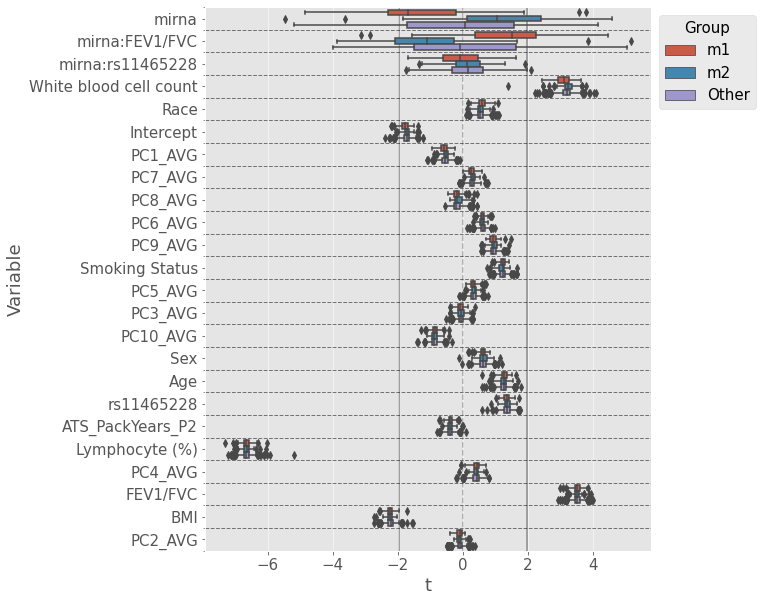

In [40]:
from matplotlib.ticker import MultipleLocator

import seaborn as sns

plt.rcParams.update({'font.size': 15})
plt.figure(figsize=[8,10])
df_coef_mirna.group = df_coef_mirna.group.str.replace('other','Other')
tmp = df_coef_mirna.replace({'Variable':dict_rename_confounders}).reset_index()


order = df_coef_mirna.groupby(['Variable','group']).t.mean().diff().xs('m2', level=1).abs().sort_values(ascending=False).rename(index=dict_rename_confounders).index

ax = sns.boxplot(hue = 'group', x='t',y = 'Variable', order = order,boxprops=dict(alpha=1),data=tmp)

# add stripplot with dodge=True
#sns.stripplot(hue = 'group', x='t',y = 'Variable', data=tmp, dodge=True, ax=ax,alpha=1, ec='k',zorder=-1, linewidth=.5)

# remove extra legend handles
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title='Group', bbox_to_anchor=(1, 1), loc='upper left')

plt.axvline(0,c='black',alpha=.3,linestyle='--',zorder=-1)
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.grid(True, which='minor', color='black', lw=1, alpha=.5,linestyle='--')


plt.axvline(df_coef_mirna.query('adj_pval<0.05')['t'].abs().min(), c='black', zorder=-1,linewidth=2,alpha=.3,linestyle='-')
plt.axvline(-df_coef_mirna.query('adj_pval<0.05')['t'].abs().min(), c='black', zorder=0,linewidth=2,alpha=.3,linestyle='-',label='Significant Threshold')
ax.xaxis.grid(True, which='major', color='white', lw=1, alpha=.5,linestyle='-',zorder=-1)

plt.savefig(config.path_figures + 'ADAM_miRNA_groups.png',dpi=500)